Install Libraries


In [ ]:
!pip install -q datasets pandas matplotlib nltk spacy yake
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Imports

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import re

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import spacy
import yake


In [ ]:
nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

Load Dataset

In [ ]:
import pandas as pd

train_url = "https://huggingface.co/datasets/metaly/Corona-tweets-classification-NLP/resolve/main/Corona_NLP_train.csv"

df = pd.read_csv(train_url, encoding="ISO-8859-1")  # or encoding="latin1"
df.head()
df.columns


Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')

Set column names

In [ ]:
text_col = "OriginalTweet"
sentiment_col = "Sentiment"
date_col = "TweetAt"
location_col = "Location"


Clean the Tweet text

In [ ]:
import re

def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"@\w+", "", t)
    t = re.sub(r"#", "", t)
    t = re.sub(r"&amp;", "and", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["clean_text"] = df[text_col].apply(clean_text)
df[["OriginalTweet", "clean_text"]].head()

,OriginalTweet,clean_text
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,and and
1,advice Talk to your neighbours family to excha...,advice Talk to your neighbours family to excha...
2,Coronavirus Australia: Woolworths to give elde...,Coronavirus Australia: Woolworths to give elde...
3,My food stock is not the only one which is emp...,My food stock is not the only one which is emp...
4,"Me, ready to go at supermarket during the #COV...","Me, ready to go at supermarket during the COVI..."


Convert Date column

In [ ]:
import pandas as pd

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df[df[date_col].notna()]
df.sort_values(by=date_col, inplace=True)

df[[date_col, "clean_text"]].head()


/tmp/ipython-input-791344032.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce")


,TweetAt,clean_text
0,2020-03-16,and and
433,2020-03-16,This past week or so has been an absolute nigh...
434,2020-03-16,"""US sales of guns and ammunition soar amid cor..."
435,2020-03-16,"Ok, chaos has ensued at the Indian grocery sto..."
436,2020-03-16,Are People Avoiding Online Shopping Portals Fr...


Use dataset sentiment

In [ ]:
df["sentiment_label"] = df[sentiment_col]
df["sentiment_label"].value_counts()

,count
sentiment_label,
Positive,11422
Negative,9917
Neutral,7713
Extremely Positive,6624
Extremely Negative,5481


## Sentiment Analysis (VADER)

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download("vader_lexicon")

sid = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["clean_text"].apply(lambda x: sid.polarity_scores(x)["compound"])

def score_to_label(c):
    if c >= 0.05: return "Positive"
    elif c <= -0.05: return "Negative"
    else: return "Neutral"

df["sentiment_vader"] = df["sentiment_score"].apply(score_to_label)

df[["clean_text", "sentiment_label", "sentiment_vader"]].head()


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,clean_text,sentiment_label,sentiment_vader
0,and and,Neutral,Neutral
433,This past week or so has been an absolute nigh...,Negative,Negative
434,"""US sales of guns and ammunition soar amid cor...",Negative,Negative
435,"Ok, chaos has ensued at the Indian grocery sto...",Negative,Negative
436,Are People Avoiding Online Shopping Portals Fr...,Positive,Positive


## Sentiment Trend Graph

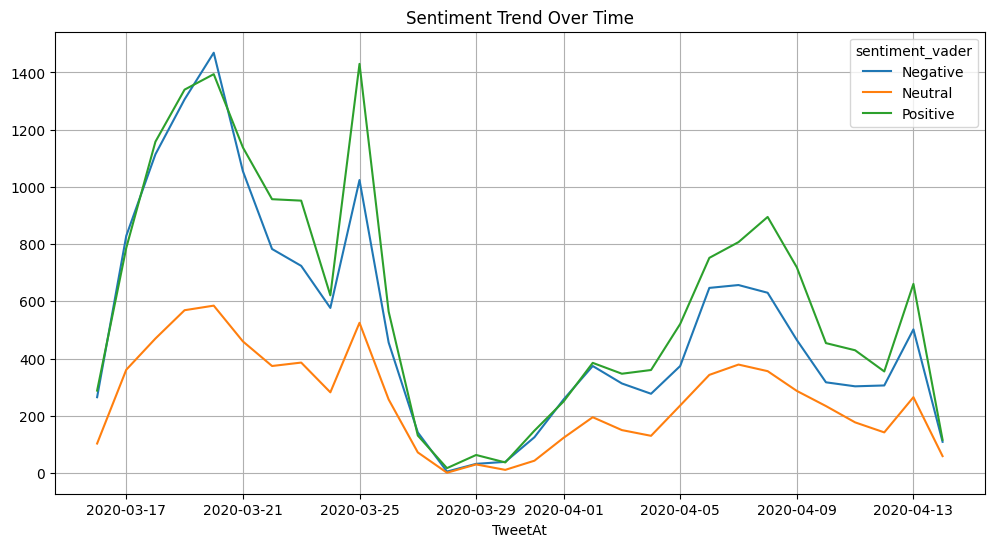

In [ ]:
sent_trend = (
    df.groupby([df[date_col].dt.date, "sentiment_vader"])
      .size()
      .unstack(fill_value=0)
)

sent_trend.plot(figsize=(12,6), title="Sentiment Trend Over Time")
plt.grid(True)
plt.show()


## Keyword Extraction (YAKE)

In [ ]:
import yake

kw_extractor = yake.KeywordExtractor(top=5, n=2)  # 5 keywords, up to 2-word phrases

def extract_keywords(t):
    try:
        return [kw for kw, score in kw_extractor.extract_keywords(t)]
    except:
        return []

df["keywords"] = df["clean_text"].apply(extract_keywords)

df[["clean_text", "keywords"]].head()


,clean_text,keywords
0,and and,[]
433,This past week or so has been an absolute nigh...,"[absolute nightmare, past week, nightmare, gro..."
434,"""US sales of guns and ammunition soar amid cor...","[panic buying, People, ammunition soar, soar a..."
435,"Ok, chaos has ensued at the Indian grocery sto...","[Indian grocery, bay area, Indian, grocery sto..."
436,Are People Avoiding Online Shopping Portals Fr...,"[People Avoiding, Avoiding Online, Online Shop..."


## Top Keywords in the Entire Dataset

In [ ]:
all_keywords = [kw for row in df["keywords"] for kw in row]
top_kw = pd.Series(all_keywords).value_counts().head(20)
top_kw


,count
grocery store,3189
coronavirus,1690
Covid,1220
supermarket,1064
COVID,1001
Coronavirus,898
store,854
hand sanitizer,792
online shopping,760
toilet paper,682


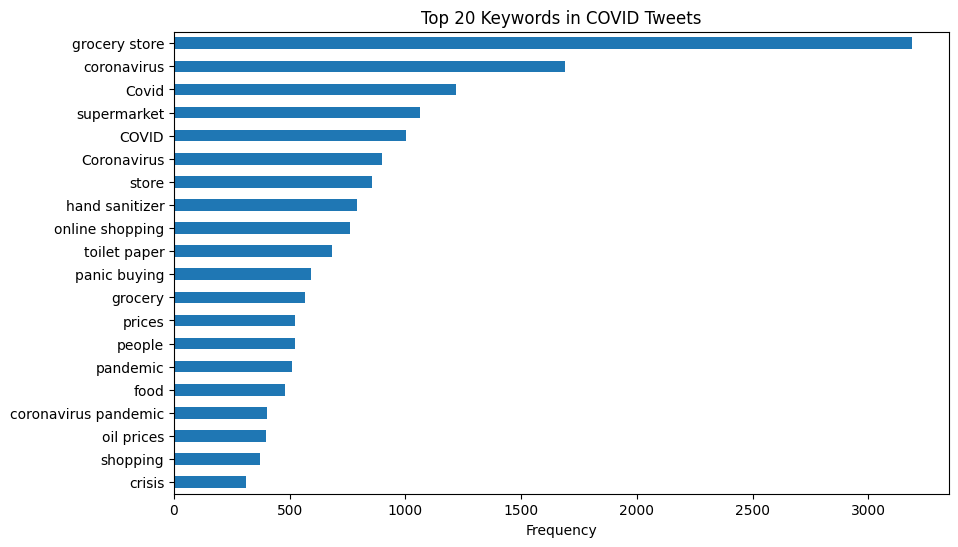

In [ ]:
top_kw.sort_values().plot(kind="barh", figsize=(10,6), title="Top 20 Keywords in COVID Tweets")
plt.xlabel("Frequency")
plt.show()


## Named Entity Recognition (NER) with spaCy


Load spaCy model

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")


Run NER on a sample (for speed)

In [ ]:
# use a sample so it doesn’t get too slow
df_ner = df.sample(min(4000, len(df)), random_state=42).copy()

def get_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df_ner["entities"] = df_ner["clean_text"].apply(get_entities)
df_ner[["clean_text", "entities"]].head()


,clean_text,entities
29931,In Desperation State Pays Up to 15 Times the N...,"[(Up to 15, CARDINAL), (Times the Normal Price..."
36165,I know people have their opinions on The Sun (...,"[(The Sun, ORG), (Karma, PERSON), (COVID?19, N..."
371,Some retail outlets like and in Renton have mo...,"[(Renton, GPE), (more than 50, CARDINAL), (the..."
6317,"America, with coronavirus, gets a taste of soc...","[(America, GPE)]"
32811,Why yes we ALL needed a piece of paper I suppo...,"[(Gerbil, PRODUCT), (DIY, ORG), (2, CARDINAL)]"


Keep only location entities (GPE, LOC)

In [ ]:
def keep_locations(ent_list):
    return [txt for txt, label in ent_list if label in ("GPE", "LOC")]

df_ner["location_entities"] = df_ner["entities"].apply(keep_locations)
df_ner[["clean_text", "location_entities"]].head()


,clean_text,location_entities
29931,In Desperation State Pays Up to 15 Times the N...,[]
36165,I know people have their opinions on The Sun (...,[]
371,Some retail outlets like and in Renton have mo...,[Renton]
6317,"America, with coronavirus, gets a taste of soc...",[America]
32811,Why yes we ALL needed a piece of paper I suppo...,[]


## Location Insights

Top locations from tweet metadata column

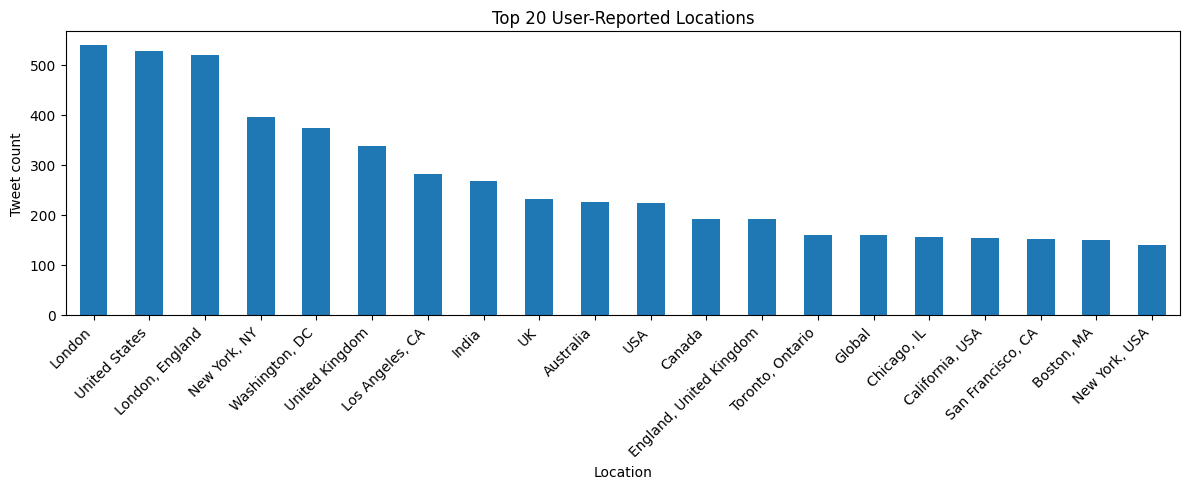

In [ ]:
df[location_col].value_counts().head(20).plot(
    kind="bar", figsize=(12,5), title="Top 20 User-Reported Locations"
)
plt.xlabel("Location")
plt.ylabel("Tweet count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Top locations mentioned inside the text (NER)

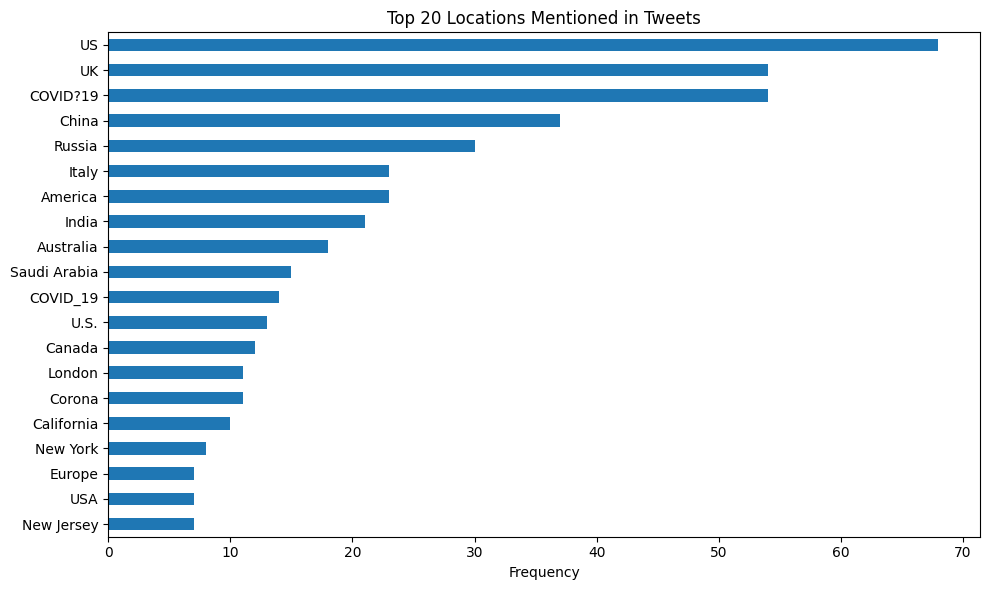

In [ ]:
all_loc_ents = [loc for row in df_ner["location_entities"] for loc in row]
loc_freq = pd.Series(all_loc_ents).value_counts().head(20)

loc_freq.sort_values().plot(
    kind="barh", figsize=(10,6), title="Top 20 Locations Mentioned in Tweets"
)
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()


# **Time‑based Trends**

Tweet volume over time

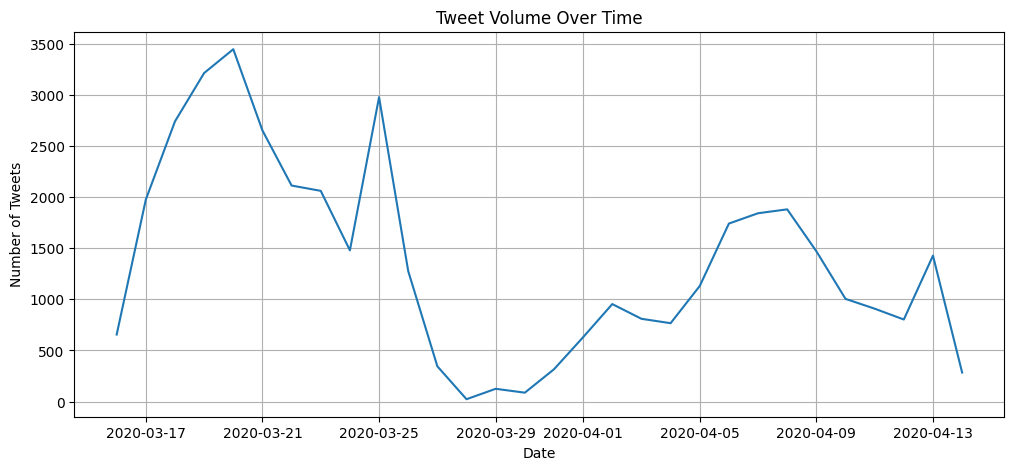

In [ ]:
daily_counts = df.groupby(df[date_col].dt.date).size()

daily_counts.plot(figsize=(12,5), title="Tweet Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.grid(True)
plt.show()


Sentiment trend over time (using VADER labels)


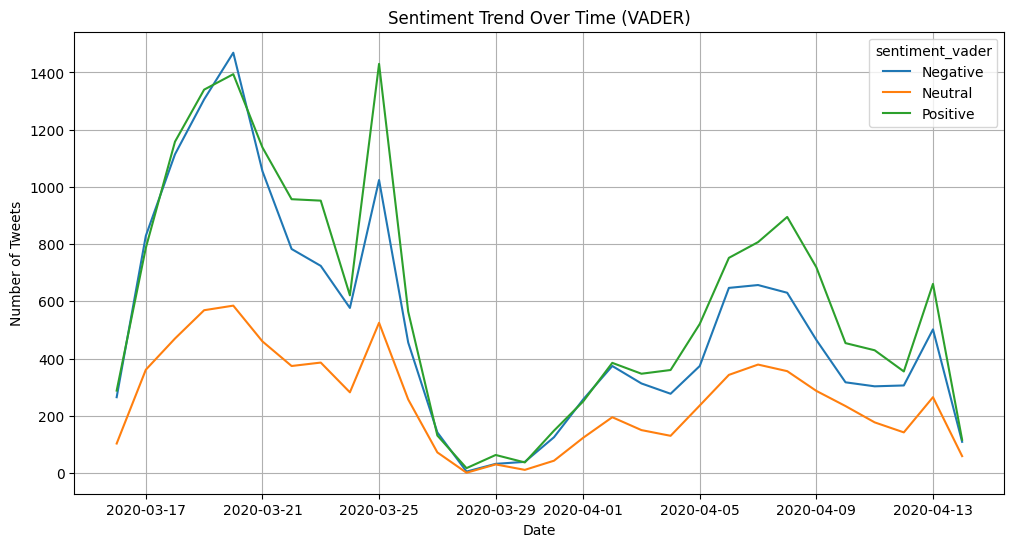

In [ ]:
sent_trend = (
    df
    .groupby([df[date_col].dt.date, "sentiment_vader"])
    .size()
    .unstack(fill_value=0)
)

sent_trend.plot(figsize=(12,6), title="Sentiment Trend Over Time (VADER)")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.grid(True)
plt.show()


## Quick Text Summary

Stats + sample tweets

In [ ]:
df["sentiment_vader"].value_counts()


,count
sentiment_vader,
Positive,18076
Negative,15476
Neutral,7605


In [ ]:
print("\nExample POSITIVE tweet:")
pos = df[df["sentiment_vader"]=="Positive"]
if len(pos) > 0:
    print(pos["clean_text"].iloc[0])
else:
    print("No positive tweets found.")

print("\nExample NEGATIVE tweet:")
neg = df[df["sentiment_vader"]=="Negative"]
if len(neg) > 0:
    print(neg["clean_text"].iloc[0])
else:
    print("No negative tweets found.")



Example POSITIVE tweet:
Are People Avoiding Online Shopping Portals From China Thanks To COVID-19?

Example NEGATIVE tweet:
This past week or so has been an absolute nightmare. Why you may ask!. I work at a grocery store and let me tell you people are just being assholes. If you go to a grocery store be nice to the people working there. We are putting our lives at risk too coronavirus
